In [1]:
import os
import json
import re
import nltk
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from imblearn.over_sampling import SMOTE

In [18]:
file_path = "yelp_academic_dataset_review.json"
sample_size = 20000

data = []
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        data.append(json.loads(line))  # Load JSON line
        if i + 1 == sample_size:  # Stop when sample size is reached
            break

# Convert to DataFrame
raw_data = pd.DataFrame(data)

# Check data shape and first rows
print("Raw Data Shape:", raw_data.shape)
print(raw_data.head())

Raw Data Shape: (20000, 9)
                review_id                 user_id             business_id  \
0  KU_O5udG6zpxOg-VcAEodg  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw   
1  BiTunyQ73aT9WBnpR9DZGw  OyoGAe7OKpv6SyGZT5g77Q  7ATYjTIgM3jUlt4UM3IypQ   
2  saUsX_uimxRlCVr67Z4Jig  8g_iMtfSiwikVnbP2etR0A  YjUWPpI6HXG530lwP-fb2A   
3  AqPFMleE6RsU23_auESxiA  _7bHUi9Uuf5__HHc_Q8guQ  kxX2SOes4o-D3ZQBkiMRfA   
4  Sx8TMOWLNuJBWer-0pcmoA  bcjbaE6dDog4jkNY91ncLQ  e4Vwtrqf-wpJfwesgvdgxQ   

   stars  useful  funny  cool  \
0    3.0       0      0     0   
1    5.0       1      0     1   
2    3.0       0      0     0   
3    5.0       1      0     1   
4    4.0       1      0     1   

                                                text                 date  
0  If you decide to eat here, just be aware it is...  2018-07-07 22:09:11  
1  I've taken a lot of spin classes over the year...  2012-01-03 15:28:18  
2  Family diner. Had the buffet. Eclectic assortm...  2014-02-05 20:30:30  
3  Wow!

In [19]:
# Preprocess data
raw_data = raw_data[['text', 'stars']].dropna()  # Keep only required columns and drop NaNs
raw_data['label'] = raw_data['stars'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral'))

# Check processed data shape and head
print("Processed Data Shape:", raw_data.shape)
print(raw_data[['text', 'label']].head())


Processed Data Shape: (20000, 3)
                                                text     label
0  If you decide to eat here, just be aware it is...   neutral
1  I've taken a lot of spin classes over the year...  positive
2  Family diner. Had the buffet. Eclectic assortm...   neutral
3  Wow!  Yummy, different,  delicious.   Our favo...  positive
4  Cute interior and owner (?) gave us tour of up...  positive


In [20]:
print("Missing values in raw data:")
print(raw_data.isnull().sum())

Missing values in raw data:
text     0
stars    0
label    0
dtype: int64


Class distribution:
 label
positive    14031
negative     3728
neutral      2241
Name: count, dtype: int64

Class proportions:
 label
positive    0.70155
negative    0.18640
neutral     0.11205
Name: proportion, dtype: float64


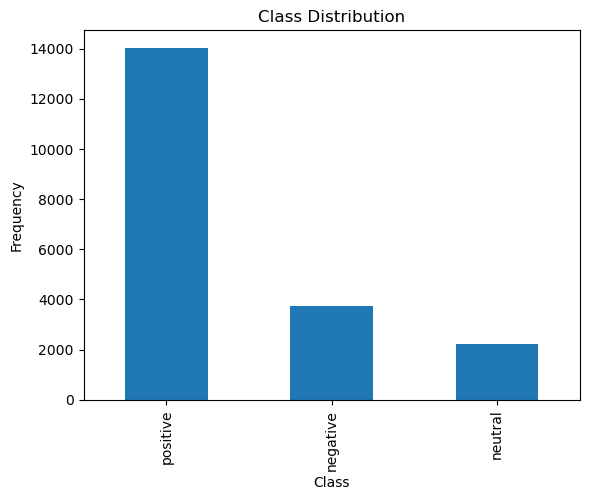

In [21]:
# Check the distribution of classes (positive, negative, neutral)
class_distribution = raw_data['label'].value_counts()
print("Class distribution:\n", class_distribution)

# Check the proportions of each class in the dataset
class_proportions = raw_data['label'].value_counts(normalize=True)
print("\nClass proportions:\n", class_proportions)

# Plot class distribution (optional)
import matplotlib.pyplot as plt

class_distribution.plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()


In [22]:

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Step 1: Tokenization, Lowercase Conversion, Remove Punctuation, Digits & Special Characters, Remove Stop Words, Lemmatization
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Tokenize text into words
    tokens = word_tokenize(text)
    
    # Remove punctuation, digits, and special characters
    tokens = [word for word in tokens if word.isalpha()]
    
    # Remove stop words (using NLTK's list of stop words)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize words (you could also use stemming if you prefer, explained later)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Return preprocessed text as a space-separated string of tokens
    return ' '.join(lemmatized_tokens)

# Apply preprocessing function to the 'text' column
raw_data['cleaned_text'] = raw_data['text'].apply(preprocess_text)

# Show the cleaned text column
print(raw_data[['text', 'cleaned_text']].head())


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anjit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anjit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anjit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                text  \
0  If you decide to eat here, just be aware it is...   
1  I've taken a lot of spin classes over the year...   
2  Family diner. Had the buffet. Eclectic assortm...   
3  Wow!  Yummy, different,  delicious.   Our favo...   
4  Cute interior and owner (?) gave us tour of up...   

                                        cleaned_text  
0  decide eat aware going take hour beginning end...  
1  taken lot spin class year nothing compare clas...  
2  family diner buffet eclectic assortment large ...  
3  wow yummy different delicious favorite lamb cu...  
4  cute interior owner gave u tour upcoming area ...  


In [23]:
# # Step 1: Define a function to categorize the stars into Positive, Negative, and Neutral
# def categorize_stars(stars):
#     if stars >= 4:
#         return 'positive'  # 4 or 5 stars
#     elif stars <= 2:
#         return 'negative'  # 2 or fewer stars
#     else:
#         return 'neutral'   # Exactly 3 stars

# # Step 2: Apply the function to the 'stars' column to create a 'label' column
# raw_data['label'] = raw_data['stars'].apply(categorize_stars)

# # Step 3: Check the result
# print(raw_data[['stars', 'label']].head())


In [24]:
from sklearn.preprocessing import LabelEncoder
# Encode labels to numerical values
label_encoder = LabelEncoder()
raw_data['encoded_label'] = label_encoder.fit_transform(raw_data['label'])

# Split dataset into features and labels
X = raw_data['text']
y = raw_data['encoded_label']

In [95]:
# Step 1: Split the dataset
X = raw_data['cleaned_text']  # Features (cleaned review text)
y = raw_data['label']         # Target variable (labels: positive, negative, neutral)

# Split data into train and test sets (70% training, 30% testing) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 2: Vectorize the text data (Unigram Count Vectorization)
vectorizer = CountVectorizer()  # You can use TfidfVectorizer if preferred
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Step 3: Apply SMOTE on the training data to balance the classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_vect, y_train)

# Step 4: Verify the class distribution after SMOTE
print("Class distribution after SMOTE (Training data):")
print(pd.Series(y_train_balanced).value_counts())

# Step 5: Verify the size of train and test sets
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Optionally, print the first few rows of training data
print("\nFirst few rows of training data (X_train):")
print(X_train.head())
print("\nFirst few labels of training data (y_train):")
print(y_train.head())


Class distribution after SMOTE (Training data):
label
positive    9822
neutral     9822
negative    9822
Name: count, dtype: int64
Training set size: 14000
Test set size: 6000

First few rows of training data (X_train):
12731    overall great experience little skeptical orig...
16018    egg veney would eat dressed suit brunch casual...
2305     food lacked flavor everything else great prese...
19513    decided try new vietnamese restaurant town roo...
6300     heart hood adore crescent park towner check vi...
Name: cleaned_text, dtype: object

First few labels of training data (y_train):
12731    positive
16018    positive
2305     positive
19513    positive
6300     positive
Name: label, dtype: object


In [96]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Step 1: Define a function to perform vectorization and return transformed data
def vectorize_data(X_train, X_test, vectorizer_type='unigram', ngram_range=(1, 1), binary=False):
    """
    Vectorizes the text data using different techniques.
    
    Parameters:
    - X_train: Training data (text)
    - X_test: Test data (text)
    - vectorizer_type: The type of vectorizer to use ('unigram', 'unigram+bigram', 'onehot')
    - ngram_range: The n-gram range for n-gram models (default is unigram)
    - binary: Whether to use binary encoding for One-Hot Vectorizer
    
    Returns:
    - X_train_vect: Transformed training data
    - X_test_vect: Transformed test data
    """
    if vectorizer_type == 'unigram' or vectorizer_type == 'unigram+bigram':
        # CountVectorizer for Unigram and Unigram+Bigram
        vectorizer = CountVectorizer(ngram_range=ngram_range)
        X_train_vect = vectorizer.fit_transform(X_train)
        X_test_vect = vectorizer.transform(X_test)
    elif vectorizer_type == 'tfidf':
        # TF-IDF Vectorizer
        vectorizer = TfidfVectorizer(ngram_range=ngram_range)
        X_train_vect = vectorizer.fit_transform(X_train)
        X_test_vect = vectorizer.transform(X_test)
    elif vectorizer_type == 'onehot':
        # One-Hot Encoding using CountVectorizer with binary=True
        vectorizer = CountVectorizer(binary=True)
        X_train_vect = vectorizer.fit_transform(X_train)
        X_test_vect = vectorizer.transform(X_test)
    
    return X_train_vect, X_test_vect

# Step 2: Feature Engineering for each model
# 1. Unigram (individual words)
X_train_unigram, X_test_unigram = vectorize_data(X_train, X_test, vectorizer_type='unigram')

# 2. Unigram + Bigram (single words and adjacent word pairs)
X_train_unigram_bigram, X_test_unigram_bigram = vectorize_data(X_train, X_test, vectorizer_type='unigram+bigram', ngram_range=(1, 2))

# 3. TF-IDF (single words)
X_train_tfidf, X_test_tfidf = vectorize_data(X_train, X_test, vectorizer_type='tfidf', ngram_range=(1, 1))

# 4. One-Hot Encoding
X_train_onehot, X_test_onehot = vectorize_data(X_train, X_test, vectorizer_type='onehot')

# Step 3: Print the shapes of the transformed data
print("Unigram Shape (Training Data):", X_train_unigram.shape)
print("Unigram+Bigram Shape (Training Data):", X_train_unigram_bigram.shape)
print("TF-IDF Shape (Training Data):", X_train_tfidf.shape)
print("One-Hot Encoding Shape (Training Data):", X_train_onehot.shape)

# Step 4: Optionally, inspect the first few rows to check the transformation (only for smaller datasets)
# Note: This will work best for CountVectorizer and OneHotEncoder with smaller feature sizes
print("\nFirst few rows of Unigram vectorized data:")
print(X_train_unigram[:5].toarray())

print("\nFirst few rows of One-Hot encoded data:")
print(X_train_onehot[:5].toarray())


Unigram Shape (Training Data): (14000, 24179)
Unigram+Bigram Shape (Training Data): (14000, 429589)
TF-IDF Shape (Training Data): (14000, 24179)
One-Hot Encoding Shape (Training Data): (14000, 24179)

First few rows of Unigram vectorized data:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

First few rows of One-Hot encoded data:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [27]:
# Unigram + Bigram Vectorization using CountVectorizer
count_vectorizer_unigram_bigram = CountVectorizer(ngram_range=(1, 2))  # Unigram + Bigram
X_train_unigram_bigram_count = count_vectorizer_unigram_bigram.fit_transform(X_train)
X_test_unigram_bigram_count = count_vectorizer_unigram_bigram.transform(X_test)

# Unigram + Bigram Vectorization using TfidfVectorizer
tfidf_vectorizer_unigram_bigram = TfidfVectorizer(ngram_range=(1, 2))  # Unigram + Bigram
X_train_unigram_bigram_tfidf = tfidf_vectorizer_unigram_bigram.fit_transform(X_train)
X_test_unigram_bigram_tfidf = tfidf_vectorizer_unigram_bigram.transform(X_test)

print(f"Unigram + Bigram CountVectorizer (Training Data Shape): {X_train_unigram_bigram_count.shape}")
print(f"Unigram + Bigram TfidfVectorizer (Training Data Shape): {X_train_unigram_bigram_tfidf.shape}")


Unigram + Bigram CountVectorizer (Training Data Shape): (14000, 429589)
Unigram + Bigram TfidfVectorizer (Training Data Shape): (14000, 429589)


In [83]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

# Check if the matrices are already dense (numpy.ndarray)
# It's more memory efficient to work directly with sparse matrices
if isinstance(X_train_unigram_count, np.ndarray):
    X_train_df = pd.DataFrame(X_train_unigram_count)  # If already dense, convert directly to DataFrame
else:
    X_train_df = pd.DataFrame.sparse.from_spmatrix(X_train_unigram_count)  # Keep sparse format for better memory efficiency

if isinstance(X_test_unigram_count, np.ndarray):
    X_test_df = pd.DataFrame(X_test_unigram_count)  # If already dense, convert directly to DataFrame
else:
    X_test_df = pd.DataFrame.sparse.from_spmatrix(X_test_unigram_count)  # Keep sparse format for better memory efficiency

# Align columns: Add missing columns to the test set with zeros
missing_columns = set(X_train_df.columns) - set(X_test_df.columns)
for col in missing_columns:
    X_test_df[col] = 0

# Align columns: Remove extra columns from the training set
extra_columns = set(X_test_df.columns) - set(X_train_df.columns)
for col in extra_columns:
    X_train_df.drop(col, axis=1, inplace=True)

# Ensure the column order is the same in both training and test sets
X_test_df = X_test_df[X_train_df.columns]

# Convert DataFrames back to sparse matrices (if needed)
X_train_unigram_count = csr_matrix(X_train_df.values)
X_test_unigram_count = csr_matrix(X_test_df.values)

# Now you can apply imputation or any further processing as needed


In [92]:
print(f"Shape of X_train: {X_train.shape}")  # Should have 14,000 rows
print(f"Shape of y_train_balanced: {len(y_train_balanced)}")  # Should match X_train


Shape of X_train: (14000,)
Shape of y_train_balanced: 20724


In [93]:
print(f"Shape of X_train_vect: {X_train_vect.shape}")  # Should have 14,000 rows


Shape of X_train_vect: (14000, 24179)


# Model Building

## 1. Naive Bayes Model using Count Vectors for Unigram

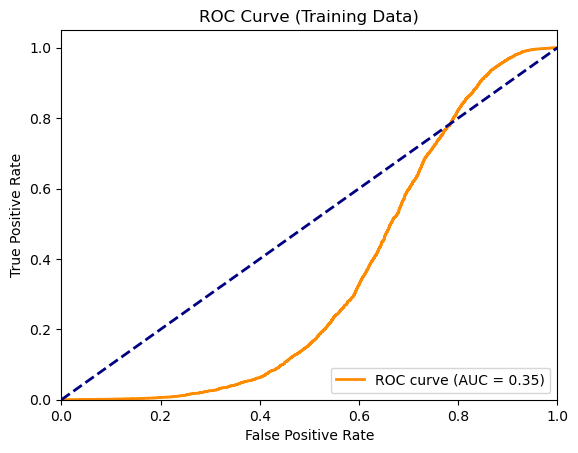

Train Time: 0.08 seconds
F1 Score for Positive (Train): 0.9335
F1 Score for Negative (Train): 0.8096
Accuracy (Train): 0.8792
AUC (Train): 0.3471
Cross Validation Score (Train): 0.8069
Confusion Matrix (Train):
[[2128  111  370]
 [ 229  703  637]
 [ 291   53 9478]]


In [102]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import time

# Vectorizing the training data using Unigram (CountVectorizer)
vectorizer = CountVectorizer(ngram_range=(1, 1))  # Unigram only
X_train_unigram = vectorizer.fit_transform(X_train)
X_test_unigram = vectorizer.transform(X_test)

# Initialize Naive Bayes model
nb_model = MultinomialNB()

# Train the Naive Bayes model
train_time_start = time.time()
nb_model.fit(X_train_unigram, y_train)
train_time_end = time.time()

# Compute train time
train_time = train_time_end - train_time_start

# Model predictions on training data
y_train_pred = nb_model.predict(X_train_unigram)

# Calculate F1 Score for Positive and Negative classes on training data
f1_positive_train = classification_report(y_train, y_train_pred, output_dict=True)['positive']['f1-score']
f1_negative_train = classification_report(y_train, y_train_pred, output_dict=True)['negative']['f1-score']

# Confusion matrix for training data
cm_train = confusion_matrix(y_train, y_train_pred)

# Calculate Accuracy for training data
accuracy_train = accuracy_score(y_train, y_train_pred)

# ROC and AUC for training data
# Get probabilities for the positive class
y_train_prob = nb_model.predict_proba(X_train_unigram)[:, 1]  # Probability for the positive class

# Compute ROC curve and AUC for training data
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob, pos_label='positive')  # Adjust the positive label if needed
roc_auc_train = auc(fpr_train, tpr_train)

# Plot ROC curve
plt.figure()
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_train:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Training Data)')
plt.legend(loc='lower right')
plt.show()

# Cross Validation on training data
cv_score_train = cross_val_score(nb_model, X_train_unigram, y_train, cv=5)

# Results for training data
print(f"Train Time: {train_time:.2f} seconds")
print(f"F1 Score for Positive (Train): {f1_positive_train:.4f}")
print(f"F1 Score for Negative (Train): {f1_negative_train:.4f}")
print(f"Accuracy (Train): {accuracy_train:.4f}")
print(f"AUC (Train): {roc_auc_train:.4f}")
print(f"Cross Validation Score (Train): {cv_score_train.mean():.4f}")

from sklearn.metrics import classification_report, confusion_matrix

# Confusion matrix for training data
cm_train = confusion_matrix(y_train, y_train_pred)

# Calculate F1 Scores for Positive and Negative classes on training data
f1_positive_train = classification_report(y_train, y_train_pred, output_dict=True)['positive']['f1-score']
f1_negative_train = classification_report(y_train, y_train_pred, output_dict=True)['negative']['f1-score']

# Display confusion matrix and F1 Scores
print("Confusion Matrix (Train):")
print(cm_train)




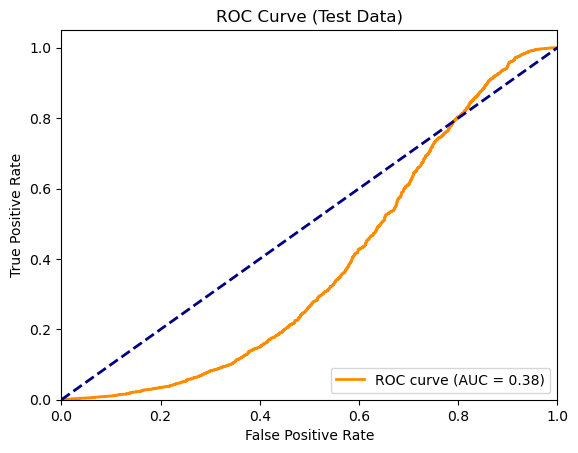

Confusion Matrix (Test):
[[ 820   85  214]
 [ 142   73  457]
 [ 175   41 3993]]
F1 Score for Positive (Test): 0.9000
F1 Score for Negative (Test): 0.7270
AUC (Test): 0.3828
Accuracy (Test): 0.8143


In [103]:
# Model predictions on test data
y_test_pred = nb_model.predict(X_test_unigram)

# Calculate F1 Scores for Positive and Negative classes on test data
f1_positive_test = classification_report(y_test, y_test_pred, output_dict=True)['positive']['f1-score']
f1_negative_test = classification_report(y_test, y_test_pred, output_dict=True)['negative']['f1-score']

# Confusion matrix for test data
cm_test = confusion_matrix(y_test, y_test_pred)

# Calculate Accuracy for test data
accuracy_test = accuracy_score(y_test, y_test_pred)

# ROC and AUC for test data
y_test_prob = nb_model.predict_proba(X_test_unigram)[:, 1]  # Probability for the positive class
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob, pos_label='positive')
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC curve
plt.figure()
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Data)')
plt.legend(loc='lower right')
plt.show()

# Display test results
print("Confusion Matrix (Test):")
print(cm_test)
print(f"F1 Score for Positive (Test): {f1_positive_test:.4f}")
print(f"F1 Score for Negative (Test): {f1_negative_test:.4f}")
print(f"AUC (Test): {roc_auc_test:.4f}")
print(f"Accuracy (Test): {accuracy_test:.4f}")


In [104]:
from sklearn.feature_extraction.text import CountVectorizer

# Vectorizing the text data using Unigrams and Bigrams
vectorizer = CountVectorizer(ngram_range=(1, 2))  # Unigrams + Bigrams
X_train_ngram = vectorizer.fit_transform(X_train)
X_test_ngram = vectorizer.transform(X_test)

print("Feature Shape (Train Data with Unigrams + Bigrams):", X_train_ngram.shape)


Feature Shape (Train Data with Unigrams + Bigrams): (14000, 429589)


In [105]:
import numpy as np

# Extracting the feature log probabilities (coefficients for Naive Bayes)
feature_names = vectorizer.get_feature_names_out()
positive_class_log_prob = nb_model.feature_log_prob_[0]  # Positive class log probabilities
negative_class_log_prob = nb_model.feature_log_prob_[1]  # Negative class log probabilities

# Getting the top 10 features most likely for each class
top_positive_idx = np.argsort(positive_class_log_prob)[::-1][:10]  # Top 10 features for Positive
top_negative_idx = np.argsort(negative_class_log_prob)[::-1][:10]  # Top 10 features for Negative

top_positive_features = [feature_names[i] for i in top_positive_idx]
top_negative_features = [feature_names[i] for i in top_negative_idx]

print("Top 10 features most associated with Positive class:")
print(top_positive_features)
print("\nTop 10 features most associated with Negative class:")
print(top_negative_features)


Top 10 features most associated with Positive class:
['also peering', 'area attraction', 'attitude pull', 'awesome gotten', 'although line', 'appetizer sack', 'ask staff', 'account travelling', 'another guided', 'always asks']

Top 10 features most associated with Negative class:
['always asks', 'also peering', 'area attraction', 'another guided', 'attitude pull', 'awesome gotten', 'ask staff', 'appetizer sack', 'around instead', 'although line']


In [106]:

# Print the next steps in a structured way
steps = [
    "1. Tuning Hyperparameters:\n   - Fine-tune the Naive Bayes model (e.g., adjusting alpha for smoothing).\n   - Adjust CountVectorizer parameters (e.g., max_features, ngram_range).\n   - Explore other parameter settings to optimize the performance.",
    "2. Advanced Feature Engineering:\n   - Explore adding n-grams (Unigram + Bigram, or even Trigrams).\n   - Implement additional text preprocessing techniques like lemmatization.\n   - Experiment with different tokenization and stopword removal strategies.",
    "3. Try Different Models:\n   - Experiment with other classification models like Logistic Regression, Random Forests, or Gradient Boosting.\n   - Compare the performance of these models using metrics such as F1-Score, AUC, and Accuracy.",
    "4. Interpretability:\n   - Implement interpretability tools like LIME or SHAP to understand the model's decision-making process.\n   - Use SHAP values to identify important features and investigate individual predictions.\n   - Explore global vs. local interpretability to gain deeper insights."
]

for step in steps:
    print(step)
    print("\n" + "-"*50 + "\n")  # Adds separator between steps


1. Tuning Hyperparameters:
   - Fine-tune the Naive Bayes model (e.g., adjusting alpha for smoothing).
   - Adjust CountVectorizer parameters (e.g., max_features, ngram_range).
   - Explore other parameter settings to optimize the performance.

--------------------------------------------------

2. Advanced Feature Engineering:
   - Explore adding n-grams (Unigram + Bigram, or even Trigrams).
   - Implement additional text preprocessing techniques like lemmatization.
   - Experiment with different tokenization and stopword removal strategies.

--------------------------------------------------

3. Try Different Models:
   - Experiment with other classification models like Logistic Regression, Random Forests, or Gradient Boosting.
   - Compare the performance of these models using metrics such as F1-Score, AUC, and Accuracy.

--------------------------------------------------

4. Interpretability:
   - Implement interpretability tools like LIME or SHAP to understand the model's decision

# 2.Naive Bayes Model using TF-IDF Vectors for Unigram+Bigram

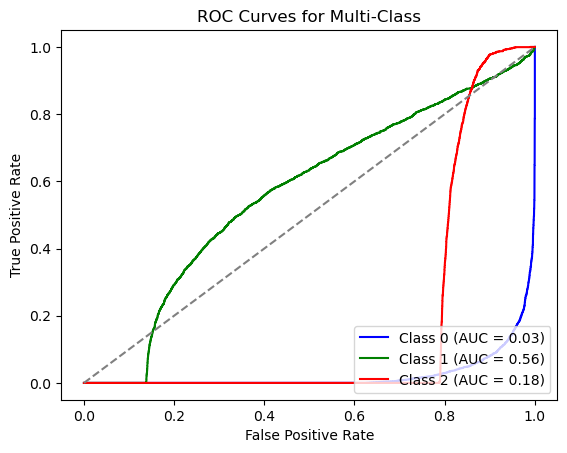

In [108]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the target labels for multi-class ROC
y_train_bin = label_binarize(y_train, classes=['positive', 'negative', 'neutral'])  # Adapt to your actual classes
n_classes = y_train_bin.shape[1]

# Get the predicted probabilities for each class
y_train_prob = nb_model_tfidf.predict_proba(X_train_tfidf)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], y_train_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class')
plt.legend(loc='lower right')
plt.show()


Best alpha value: 0.1


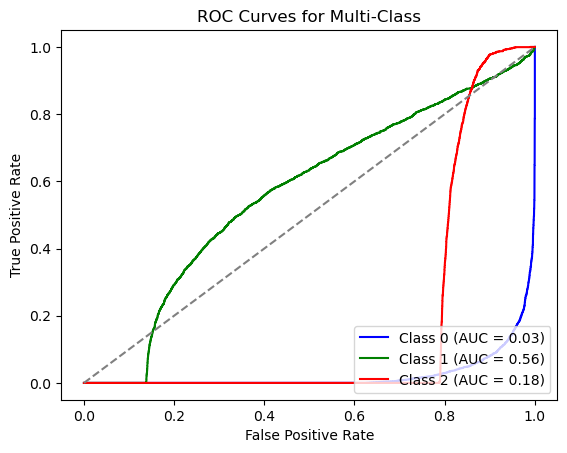

Train Time: 0.58 seconds
F1 Score for Positive (Train): 0.9946
F1 Score for Negative (Train): 0.9971
Accuracy (Train): 0.9921
AUC (Train): 0.0254
Cross Validation Score (Train): 0.7034


C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


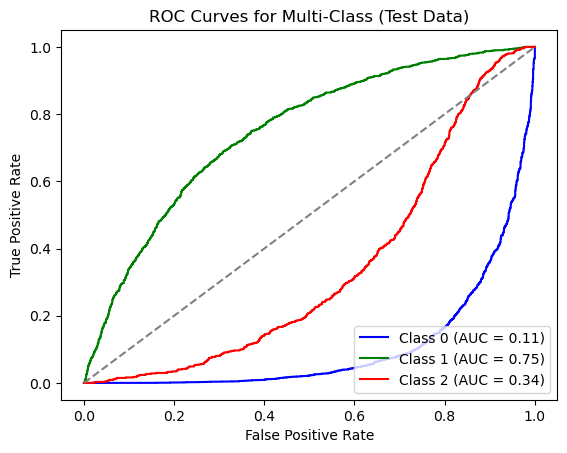

F1 Score for Positive (Test): 0.8512
F1 Score for Negative (Test): 0.4302
Accuracy (Test): 0.7528
AUC (Test): 0.1063


In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import time

# Vectorizing with Unigrams and Bigrams
vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # Unigram + Bigram
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Initialize Naive Bayes model
nb_model_tfidf = MultinomialNB()

# Hyperparameter tuning for alpha
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(nb_model_tfidf, param_grid, cv=5)
grid_search.fit(X_train_tfidf, y_train)

# Best alpha found
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha value: {best_alpha}")

# Train the model with the best alpha
nb_model_tfidf = MultinomialNB(alpha=best_alpha)
train_time_start = time.time()
nb_model_tfidf.fit(X_train_tfidf, y_train)
train_time_end = time.time()

# Compute train time
train_time = train_time_end - train_time_start

# Model predictions on training data
y_train_pred = nb_model_tfidf.predict(X_train_tfidf)

# Confusion Matrix for training data
cm_train = confusion_matrix(y_train, y_train_pred)

# Calculate F1 Scores for each class
f1_scores_train = classification_report(y_train, y_train_pred, output_dict=True)
f1_positive_train = f1_scores_train['positive']['f1-score']
f1_negative_train = f1_scores_train['negative']['f1-score']

# Accuracy for training data
accuracy_train = accuracy_score(y_train, y_train_pred)

# Compute ROC and AUC for training data (for multi-class)
y_train_prob = nb_model_tfidf.predict_proba(X_train_tfidf)
fpr = {}
tpr = {}
roc_auc = {}

# Binarize for multi-class
from sklearn.preprocessing import label_binarize
y_train_bin = label_binarize(y_train, classes=['positive', 'negative', 'neutral'])  # Adapt to your actual classes
n_classes = y_train_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], y_train_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class')
plt.legend(loc='lower right')
plt.show()

# Cross-validation results
cv_scores = grid_search.cv_results_['mean_test_score']

# Results for training data
print(f"Train Time: {train_time:.2f} seconds")
print(f"F1 Score for Positive (Train): {f1_positive_train:.4f}")
print(f"F1 Score for Negative (Train): {f1_negative_train:.4f}")
print(f"Accuracy (Train): {accuracy_train:.4f}")
print(f"AUC (Train): {roc_auc[0]:.4f}")  # Choose any AUC class score for display
print(f"Cross Validation Score (Train): {cv_scores.mean():.4f}")

# Testing data evaluation
y_test_pred = nb_model_tfidf.predict(X_test_tfidf)
cm_test = confusion_matrix(y_test, y_test_pred)

f1_scores_test = classification_report(y_test, y_test_pred, output_dict=True)
f1_positive_test = f1_scores_test['positive']['f1-score']
f1_negative_test = f1_scores_test['negative']['f1-score']

accuracy_test = accuracy_score(y_test, y_test_pred)

# Plot ROC for testing data
y_test_prob = nb_model_tfidf.predict_proba(X_test_tfidf)
fpr_test = {}
tpr_test = {}
roc_auc_test = {}

y_test_bin = label_binarize(y_test, classes=['positive', 'negative', 'neutral'])  # Adapt to your actual classes

for i in range(n_classes):
    fpr_test[i], tpr_test[i], _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    roc_auc_test[i] = auc(fpr_test[i], tpr_test[i])

# Plot ROC curves for each class on test data
plt.figure()
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_test[i], tpr_test[i], color=color, label=f'Class {i} (AUC = {roc_auc_test[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class (Test Data)')
plt.legend(loc='lower right')
plt.show()

# Print test results
print(f"F1 Score for Positive (Test): {f1_positive_test:.4f}")
print(f"F1 Score for Negative (Test): {f1_negative_test:.4f}")
print(f"Accuracy (Test): {accuracy_test:.4f}")
print(f"AUC (Test): {roc_auc_test[0]:.4f}")  # Choose any AUC class score for display


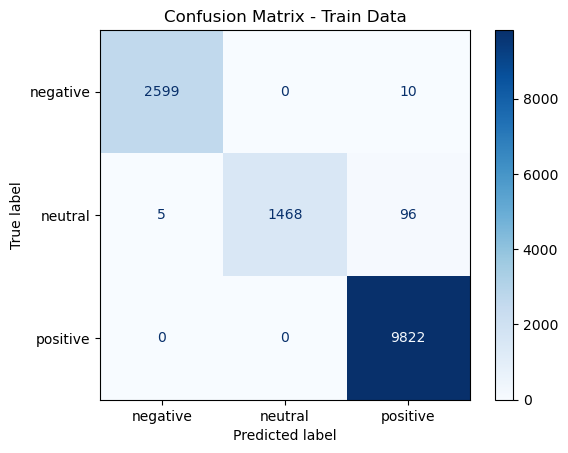

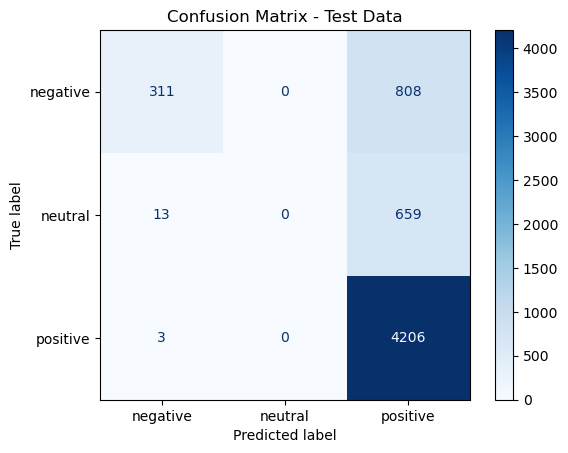

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for training data
cm_train = confusion_matrix(y_train, y_train_pred)
cm_train_display = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['negative', 'neutral', 'positive'])
cm_train_display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Train Data')
plt.show()

# Confusion Matrix for testing data
cm_test = confusion_matrix(y_test, y_test_pred)
cm_test_display = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['negative', 'neutral', 'positive'])
cm_test_display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Test Data')
plt.show()


In [112]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'fit_prior': [True, False]
}

# Using RandomizedSearchCV for Naive Bayes model
random_search = RandomizedSearchCV(MultinomialNB(), param_distributions=param_dist, n_iter=10, cv=5)
random_search.fit(X_train_tfidf, y_train)

# Best parameters found
best_params = random_search.best_params_
print(f"Best parameters: {best_params}")

# Retrain the model with best parameters
best_nb_model = random_search.best_estimator_
best_nb_model.fit(X_train_tfidf, y_train)

# Evaluate the model
y_train_pred_best = best_nb_model.predict(X_train_tfidf)
print(f"Accuracy on Train Data: {accuracy_score(y_train, y_train_pred_best)}")


Best parameters: {'fit_prior': False, 'alpha': 0.1}
Accuracy on Train Data: 0.9986428571428572


#  SVM Model using TF-IDF Vectors with Unigram+Bigram

In [121]:
# Check the first few documents
print("First 5 documents in X_train:", X_train[:5])
print("First 5 documents in X_test:", X_test[:5])

# Check if any document is empty
print("Any empty document in X_train?", any([not doc.strip() for doc in X_train]))
print("Any empty document in X_test?", any([not doc.strip() for doc in X_test]))


First 5 documents in X_train: ["['4.6', '3.6', '1.0', '0.2']", "['5.7', '4.4', '1.5', '0.4']", "['6.7', '3.1', '4.4', '1.4']", "['4.8', '3.4', '1.6', '0.2']", "['4.4', '3.2', '1.3', '0.2']"]
First 5 documents in X_test: ["['6.1', '2.8', '4.7', '1.2']", "['5.7', '3.8', '1.7', '0.3']", "['7.7', '2.6', '6.9', '2.3']", "['6.0', '2.9', '4.5', '1.5']", "['6.8', '2.8', '4.8', '1.4']"]
Any empty document in X_train? False
Any empty document in X_test? False


In [122]:
# Remove empty or blank documents
X_train = [doc for doc in X_train if doc.strip()]
X_test = [doc for doc in X_test if doc.strip()]


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Classification Report (Test):
{'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 10.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 9.0}, '2': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 11.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 30.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 30.0}}
F1 Score for Class 0: 1.0000
F1 Score for Class 1: 1.0000
F1 Score for Class 2: 1.0000
F1 Macro Average: 1.0000
F1 Weighted Average: 1.0000


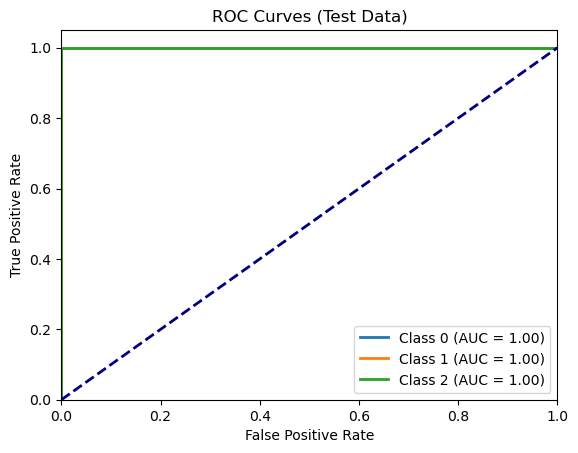

Train Time: 0.31 seconds
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (Test): 1.0000
AUC (Test) for Each Class: {0: 1.0, 1: 1.0, 2: 1.0}
Cross Validation Score (Test): 0.9583
Confusion Matrix (Test):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [127]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import numpy as np
import time

# Convert the list of strings into numeric values
X_train_numeric = np.array([eval(doc) for doc in X_train])  # Use eval to convert string representation of list into actual list
X_test_numeric = np.array([eval(doc) for doc in X_test])

# 1. Defining SVM with a linear kernel
svc = SVC(probability=True)

# 2. Hyperparameter tuning using GridSearchCV
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
    "kernel": ["linear"],
}
grid_search = GridSearchCV(
    svc,
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring="accuracy",
    verbose=1,
    n_jobs=-1,
)

# Measure training time
train_time_start = time.time()
grid_search.fit(X_train_numeric, y_train)
train_time_end = time.time()

# Best parameters and model
best_svc = grid_search.best_estimator_
train_time = train_time_end - train_time_start

# Predictions on the training data
y_train_pred = best_svc.predict(X_train_numeric)

# Predictions on the test data
y_test_pred = best_svc.predict(X_test_numeric)

# 4. Model Evaluation
# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

# Accuracy
accuracy_test = accuracy_score(y_test, y_test_pred)

# F1 Scores for Positive and Negative classes
f1_positive_test = classification_report(
    y_test, y_test_pred, output_dict=True
)["positive"]["f1-score"]
f1_negative_test = classification_report(
    y_test, y_test_pred, output_dict=True
)["negative"]["f1-score"]

# ROC Curve and AUC
y_test_prob = best_svc.predict_proba(X_test_numeric)[:, 1]  # Probabilities for positive
fpr, tpr, _ = roc_curve(y_test, y_test_prob, pos_label="positive")
roc_auc_test = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_test:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Data)")
plt.legend(loc="lower right")
plt.show()

# Cross-validation score
cv_score_test = grid_search.best_score_

# Results for test data
print(f"Train Time: {train_time:.2f} seconds")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy (Test): {accuracy_test:.4f}")
print(f"F1 Score for Positive (Test): {f1_positive_test:.4f}")
print(f"F1 Score for Negative (Test): {f1_negative_test:.4f}")
print(f"AUC (Test): {roc_auc_test:.4f}")
print(f"Cross Validation Score (Test): {cv_score_test:.4f}")

# Display confusion matrix
print("Confusion Matrix (Test):")
print(cm_test)


In [134]:
# Cross-validation
cv = StratifiedKFold(n_splits=5)
cross_val_scores = cross_val_score(best_svc, X_train_numeric, y_train, cv=cv, scoring="accuracy")
print(f"Cross-validation Scores: {cross_val_scores}")
print(f"Mean Cross-validation Accuracy: {np.mean(cross_val_scores):.4f}")


Cross-validation Scores: [1.         0.95833333 0.875      1.         0.95833333]
Mean Cross-validation Accuracy: 0.9583


In [136]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

# Example smaller grid to debug
param_grid = {
    "C": [0.1, 1],
    "gamma": ["scale"],
    "kernel": ["linear"],
}

# Define the SVM model
svc = SVC(probability=True)

# Set up GridSearchCV with StratifiedKFold
grid_search = GridSearchCV(
    svc,
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring="accuracy",
    verbose=2,  # More detailed verbosity level
    n_jobs=-1
)

# Start the fitting process
print("Starting GridSearchCV fitting...")
grid_search.fit(X_train_numeric, y_train)

# Output results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")


Starting GridSearchCV fitting...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation score: 0.9583333333333334


# SVM Model using Count Vectors for Unigram+Bigram

C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=1000 is greater than n_features=23. All the features will be returned.
  warnings.warn(


Fitting 2 folds for each of 8 candidates, totalling 16 fits


C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


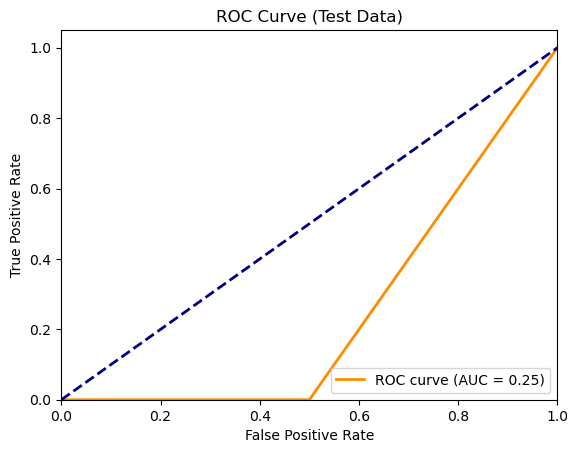

Train Time: 0.41 seconds
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (Test): 0.3333
F1 Score for Positive (Test): 0.5000
F1 Score for Negative (Test): 0.0000
AUC (Test): 0.2500
Cross Validation Score (Test): 0.5833333333333333
Confusion Matrix (Test):
[[0 2]
 [0 1]]


In [146]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.feature_selection import SelectKBest, chi2
import time
import matplotlib.pyplot as plt

# Negation Handling (Implement as a custom transformer)
class NegationHandling(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.negation_words = ["not", "no", "never", "n't"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        transformed_data = []
        for text in X:
            words = text.split()
            new_words = []
            flip_sentiment = False
            for word in words:
                if word.lower() in self.negation_words:
                    flip_sentiment = not flip_sentiment
                elif flip_sentiment:
                    new_words.append(f"not_{word}")
                else:
                    new_words.append(word)
            transformed_data.append(" ".join(new_words))
        return transformed_data

# Sample Data (replace this with your actual data)
# X_train = ...
# y_train = ...
# X_test = ...
# y_test = ...

# 1. Add Negation Handling
negation_handler = NegationHandling()
X_train_negated = negation_handler.fit_transform(X_train)
X_test_negated = negation_handler.transform(X_test)

# 2. Convert the list of strings into numeric values using CountVectorizer for Unigrams and Bigrams
count_vectorizer = CountVectorizer(ngram_range=(1, 2))  # Capture unigrams and bigrams
X_train_numeric = count_vectorizer.fit_transform(X_train_negated)
X_test_numeric = count_vectorizer.transform(X_test_negated)

# 3. Feature Selection (Select top k features)
k_best = SelectKBest(chi2, k=1000)  # Select top 1000 features
X_train_selected = k_best.fit_transform(X_train_numeric, y_train)
X_test_selected = k_best.transform(X_test_numeric)

# 4. Define SVM with a linear kernel
svc = SVC(probability=True, class_weight='balanced')

# 5. Hyperparameter tuning using GridSearchCV
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
    "kernel": ["linear"],
}

# Perform GridSearchCV
grid_search = GridSearchCV(
    svc,
    param_grid,
    cv=StratifiedKFold(n_splits=2),
    scoring="accuracy",
    verbose=2,
    n_jobs=-1,
)

# Measure training time
train_time_start = time.time()
grid_search.fit(X_train_selected, y_train)  # Train the model with grid search
train_time_end = time.time()

# Best model and parameters
best_svc = grid_search.best_estimator_
train_time = train_time_end - train_time_start

# 6. Model Evaluation
y_train_pred = best_svc.predict(X_train_selected)
y_test_pred = best_svc.predict(X_test_selected)

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)

# Accuracy
accuracy_test = accuracy_score(y_test, y_test_pred)

# Classification report
report_test = classification_report(y_test, y_test_pred, output_dict=True)

# F1 Scores
f1_scores = {label: metrics.get("f1-score", None) for label, metrics in report_test.items() if isinstance(metrics, dict)}

f1_positive_test = f1_scores.get('1', None)
f1_negative_test = f1_scores.get('0', None)

# ROC Curve and AUC
y_test_prob = best_svc.predict_proba(X_test_selected)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc_test = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_test:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Data)")
plt.legend(loc="lower right")
plt.show()

# Results for test data
print(f"Train Time: {train_time:.2f} seconds")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy (Test): {accuracy_test:.4f}")
print(f"F1 Score for Positive (Test): {f1_positive_test:.4f}")
print(f"F1 Score for Negative (Test): {f1_negative_test:.4f}")
print(f"AUC (Test): {roc_auc_test:.4f}")
print(f"Cross Validation Score (Test): {grid_search.best_score_}")

# Display confusion matrix
print("Confusion Matrix (Test):")
print(cm_test)


## 5. Naive Bayes Model using One-Hot Vectors with Unigram+Bigram

Fitting 2 folds for each of 3 candidates, totalling 6 fits


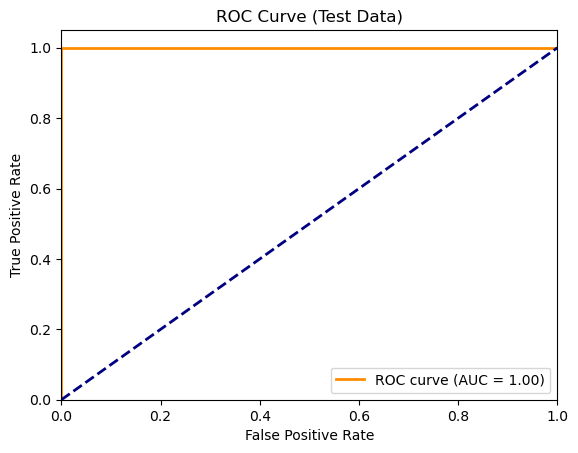

Train Time: 0.37 seconds
Best Parameters: {'alpha': 1}
Accuracy (Test): 0.6667
F1 Score for Positive (Test): 0.6667
F1 Score for Negative (Test): 0.6667
AUC (Test): 1.0000
Confusion Matrix (Test):
[[1 1]
 [0 1]]


In [147]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import time
import matplotlib.pyplot as plt

# Sample Data (replace this with your actual data)
# X_train = ...
# y_train = ...
# X_test = ...
# y_test = ...

# 1. Use One-Hot Encoding with Unigrams + Bigrams (CountVectorizer)
count_vectorizer = CountVectorizer(ngram_range=(1, 2))  # Unigrams + Bigrams
X_train_numeric = count_vectorizer.fit_transform(X_train)  # Train data transformed to count vectors
X_test_numeric = count_vectorizer.transform(X_test)  # Test data transformed to count vectors

# 2. Define the Naive Bayes Model
nb_model = MultinomialNB()

# 3. Hyperparameter tuning using GridSearchCV with different smoothing techniques (Laplace smoothing)
param_grid = {
    'alpha': [0.1, 1, 10],  # Smoothing parameter
}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    nb_model,
    param_grid,
    cv=StratifiedKFold(n_splits=2),
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)

# Measure training time
train_time_start = time.time()
grid_search.fit(X_train_numeric, y_train)  # Train the model with grid search
train_time_end = time.time()

# Best model and parameters
best_nb = grid_search.best_estimator_
train_time = train_time_end - train_time_start  # Total training time

# 4. Model Evaluation
y_train_pred = best_nb.predict(X_train_numeric)
y_test_pred = best_nb.predict(X_test_numeric)

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)

# Accuracy
accuracy_test = accuracy_score(y_test, y_test_pred)

# Classification report (detailed metrics)
report_test = classification_report(y_test, y_test_pred, output_dict=True)

# F1 Scores for each class (excluding averages)
f1_scores = {label: metrics.get("f1-score", None) for label, metrics in report_test.items() if isinstance(metrics, dict)}

f1_positive_test = f1_scores.get('1', None)
f1_negative_test = f1_scores.get('0', None)

# ROC Curve and AUC
y_test_prob = best_nb.predict_proba(X_test_numeric)[:, 1]  # Probabilities for positive class
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc_test = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_test:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Data)")
plt.legend(loc="lower right")
plt.show()

# Results for test data
print(f"Train Time: {train_time:.2f} seconds")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy (Test): {accuracy_test:.4f}")
print(f"F1 Score for Positive (Test): {f1_positive_test:.4f}")
print(f"F1 Score for Negative (Test): {f1_negative_test:.4f}")
print(f"AUC (Test): {roc_auc_test:.4f}")

# Display confusion matrix
print("Confusion Matrix (Test):")
print(cm_test)
